In [53]:
import os
import tempfile
import psutil

os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "matplotlib-cache"))
os.environ.setdefault("XDG_CACHE_HOME", os.path.join(tempfile.gettempdir(), "xdg-cache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)
os.makedirs(os.environ["XDG_CACHE_HOME"], exist_ok=True)

pid = os.getpid()
print("PID:", pid)

p = psutil.Process(pid)
print("Name:", p.name())
print("Status:", p.status())
try:
    memory = p.memory_full_info()
except psutil.Error:
    memory = p.memory_info()
print("Memory:", memory)


PID: 41173
Name: python3.12
Status: running
Memory: pfullmem(rss=679264256, vms=446790942720, pfaults=67950, pageins=3, uss=605519872)


# Set Configuration

In [54]:
import math
from diffusion_hash_inv.config import MainConfig, HashConfig, MessageConfig, OutputConfig, Byte2RGBConfig
from diffusion_hash_inv.main import MainEP
from diffusion_hash_inv.utils import FileIO
from diffusion_hash_inv.main import RuntimeConfig

length = 256
TARGET_IMAGE_COUNT = 10_000
IMAGES_PER_LOG_ESTIMATE = 71
iteration = 10_000
RUN = True

main_cfg = MainConfig(
    verbose_flag=False,
    clean_flag=True,
    debug_flag=False,
    make_image_flag=True,
)
hash_cfg = HashConfig(
    hash_alg="md5",
    length=length,
)
message_cfg = MessageConfig(
    message_flag=False,
    length=length,
    random_flag=True,
    seed_flag=True,
)
output_cfg = OutputConfig()
byte2rgb_cfg = Byte2RGBConfig()
runtime_cfg = RuntimeConfig(
    main=main_cfg,
    message=message_cfg,
    hash=hash_cfg,
    output=output_cfg,
    rgb=byte2rgb_cfg,
)

io_controller = FileIO(main_config=main_cfg, output_cfg=output_cfg)
print(f"Iterations: {iteration} (~{iteration * IMAGES_PER_LOG_ESTIMATE:,} images)")


Clearing generated files...

Iterations: 10000 (~710,000 images)


In [55]:
if RUN:
    main = MainEP(runtime_config=runtime_cfg, file_controller=io_controller)
    main.run(iteration=iteration)

Main Entry Point Initialized.
Program Start Time: 2026-05-09 03:46:54.424984+09:00
Hash Algorithm: MD5
Message Length: 256
Data Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data
Output Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output


Hash Generation Progress: 100%|██████████| 10000/10000 [00:10<00:00, 983.38iteration/s, Hash Algorithm=MD5, Message Length=256]


Hash Calculation time: 10 s, 171 ms, 568 us, 666 ns
Process completed.

RGB Image Maker Module Loaded.
RGB Image Maker Initialized.
Found 10000 logs to process.
Expected 710000 images to write (71 images per log).


Processing Logs: 100%|██████████| 10000/10000 [10:03<00:00, 16.56log/s, images=710000]

Image writing completed: 710000 images.
RGB Image Maker execution time: 604 s, 7 ms, 239 us, 83 ns
RGB Image Maker process completed.

Total Execution Time: 614 s, 178 ms, 807 us, 749 ns



In [56]:
from diffusion_hash_inv.logger.logger import Logs
from diffusion_hash_inv.analyze import iter_beta_schedules, summarize_beta_schedules


def stream_logs():
    return Logs.iter_logs(io_controller, hash_cfg, main_cfg)


log_count = sum(1 for _ in stream_logs())
print(f"Logs available: {log_count}")


Logs available: 10000


In [57]:
def stream_schedules():
    return iter_beta_schedules(stream_logs(), step_name="4th Step")


# Beta Scheduling
## Approach 1
**method**  
1. Cumulative all bytes from Hash algorithm calculation logs  
2. Make new Beta Schedule by multiply Base Beta Schedule and Cumulative block


In [58]:
summary = summarize_beta_schedules(stream_schedules())
assert summary.count == log_count, f"Step 4 logs mismatch: {summary.count} != {log_count}"
print(f"Schedules: {summary.count}")
print(f"Schedule length: {summary.length}")


Schedules: 10000
Schedule length: 1056


In [59]:
# Step 4 schedules are streamed by diffusion_hash_inv.analyze.iter_beta_schedules.
# The notebook keeps only online aggregates plus the first schedule for plotting.


In [60]:
first_schedule = summary.first


In [61]:
print(f"Summary count: {summary.count}")
print(f"Summary length: {summary.length}")
print(f"First schedule preview: {first_schedule[:16]}")


Summary count: 10000
Summary length: 1056
First schedule preview: [1.000e+00 3.600e+01 1.050e+02 2.080e+02 3.450e+02 5.160e+02 7.210e+02 9.600e+02 1.214e+03 1.434e+03 1.620e+03 1.772e+03 1.890e+03 1.974e+03 2.024e+03
 2.040e+03]


In [62]:
if main_cfg.verbose_flag:
    width = len(str(summary.count))
    print(f"Beta Schedule {0:0{width}}:")
    print(f"{' ' * 4}Beta preview: {first_schedule[:64]}")


In [63]:
import numpy as np

betas = np.linspace(start=1e-4, stop=2e-2, num=summary.length, dtype=np.float64)


In [64]:
sn_array = first_schedule.reshape(1, -1).astype(np.uint64)
_min = summary.minimum
_max = summary.maximum
mean = summary.mean
var = summary.variance
std = summary.std

candidate_betas = np.multiply(mean, betas)
beta_candidate_from_multiply = np.array(candidate_betas, dtype=np.float64)

np.set_printoptions(threshold=32, linewidth=160)

sn_min = np.min(mean, axis=0)
sn_max = np.max(mean, axis=0)
ori_beta_min = np.min(betas)
ori_beta_max = np.max(betas)

print(f"SN shape: ({summary.count}, {summary.length})")
print(f"Min preview: {_min[:8]}")
print(f"Max preview: {_max[:8]}")
print(f"Mean preview: {mean[:8]}")
print(f"Variance preview: {var[:8]}")
print(f"Standard deviation preview: {std[:8]}")


SN shape: (10000, 1056)
Min preview: [  1.  36. 105. 208. 345. 516. 721. 960.]
Max preview: [  1.  36. 105. 208. 345. 516. 721. 960.]
Mean preview: [  1.  36. 105. 208. 345. 516. 721. 960.]
Variance preview: [0. 0. 0. 0. 0. 0. 0. 0.]
Standard deviation preview: [0. 0. 0. 0. 0. 0. 0. 0.]


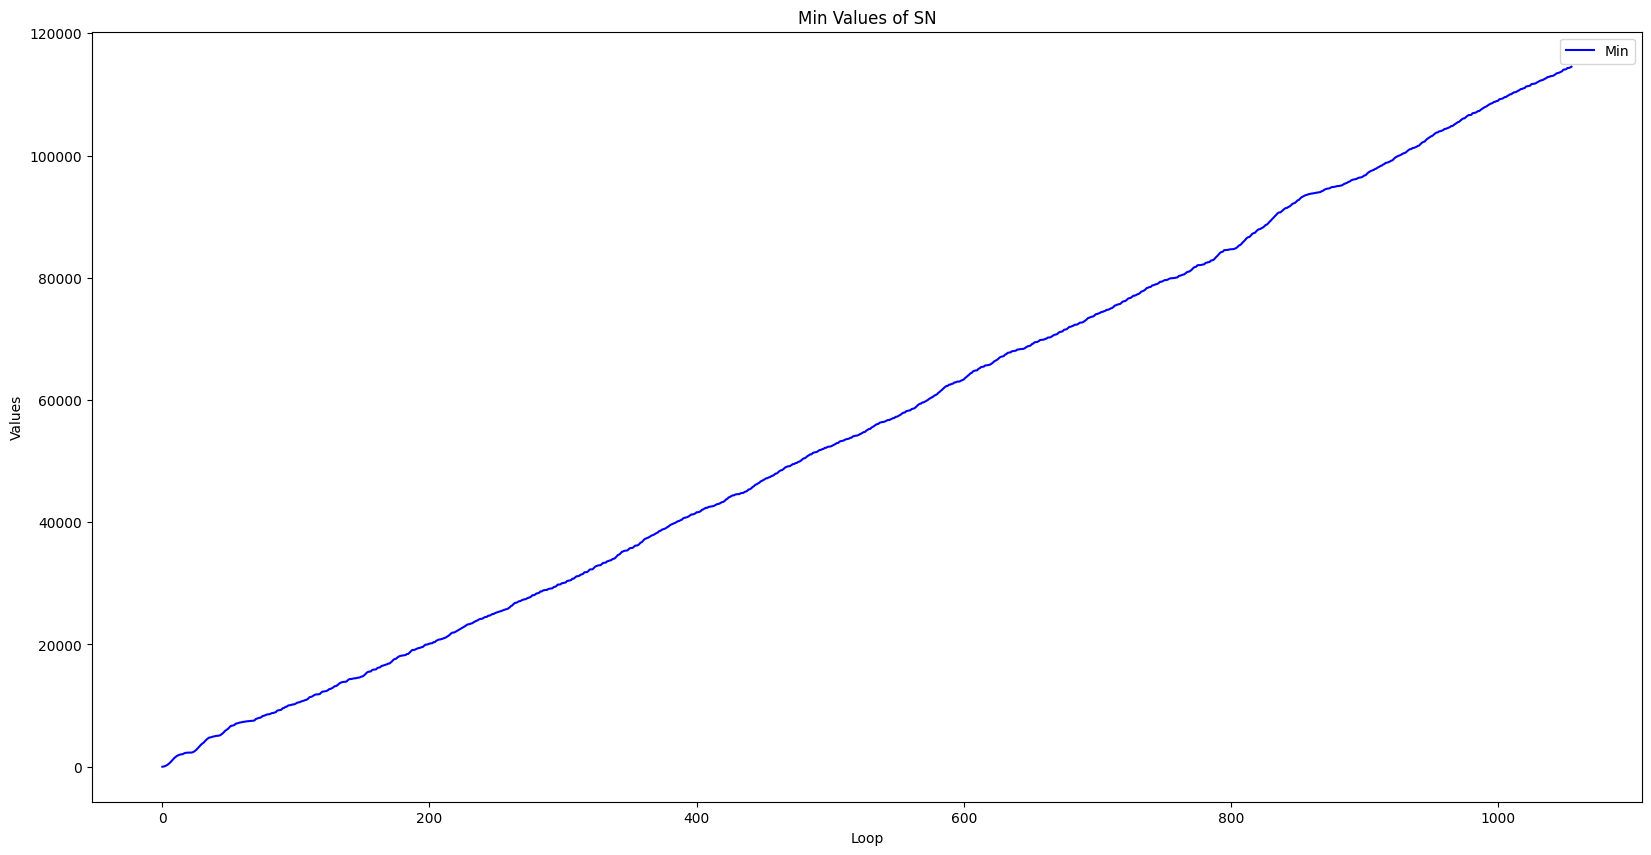

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
plt.plot(_min, label='Min', color='blue')
plt.legend()
plt.title('Min Values of SN')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

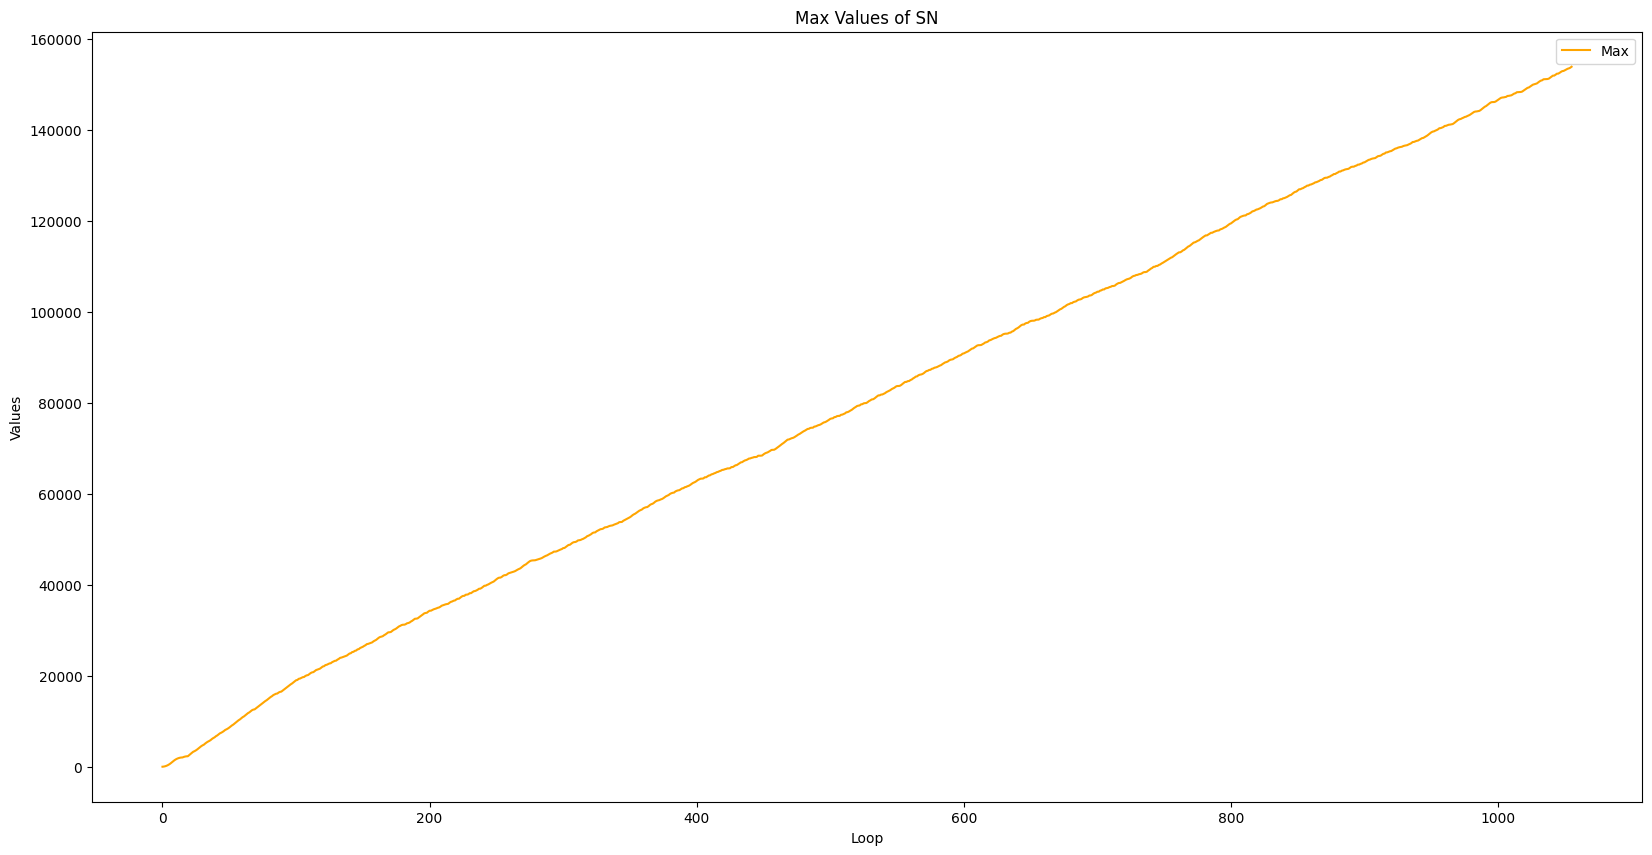

In [66]:
plt.figure(figsize=(20, 10))
plt.plot(_max, label='Max', color='orange')
plt.legend()
plt.title('Max Values of SN')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

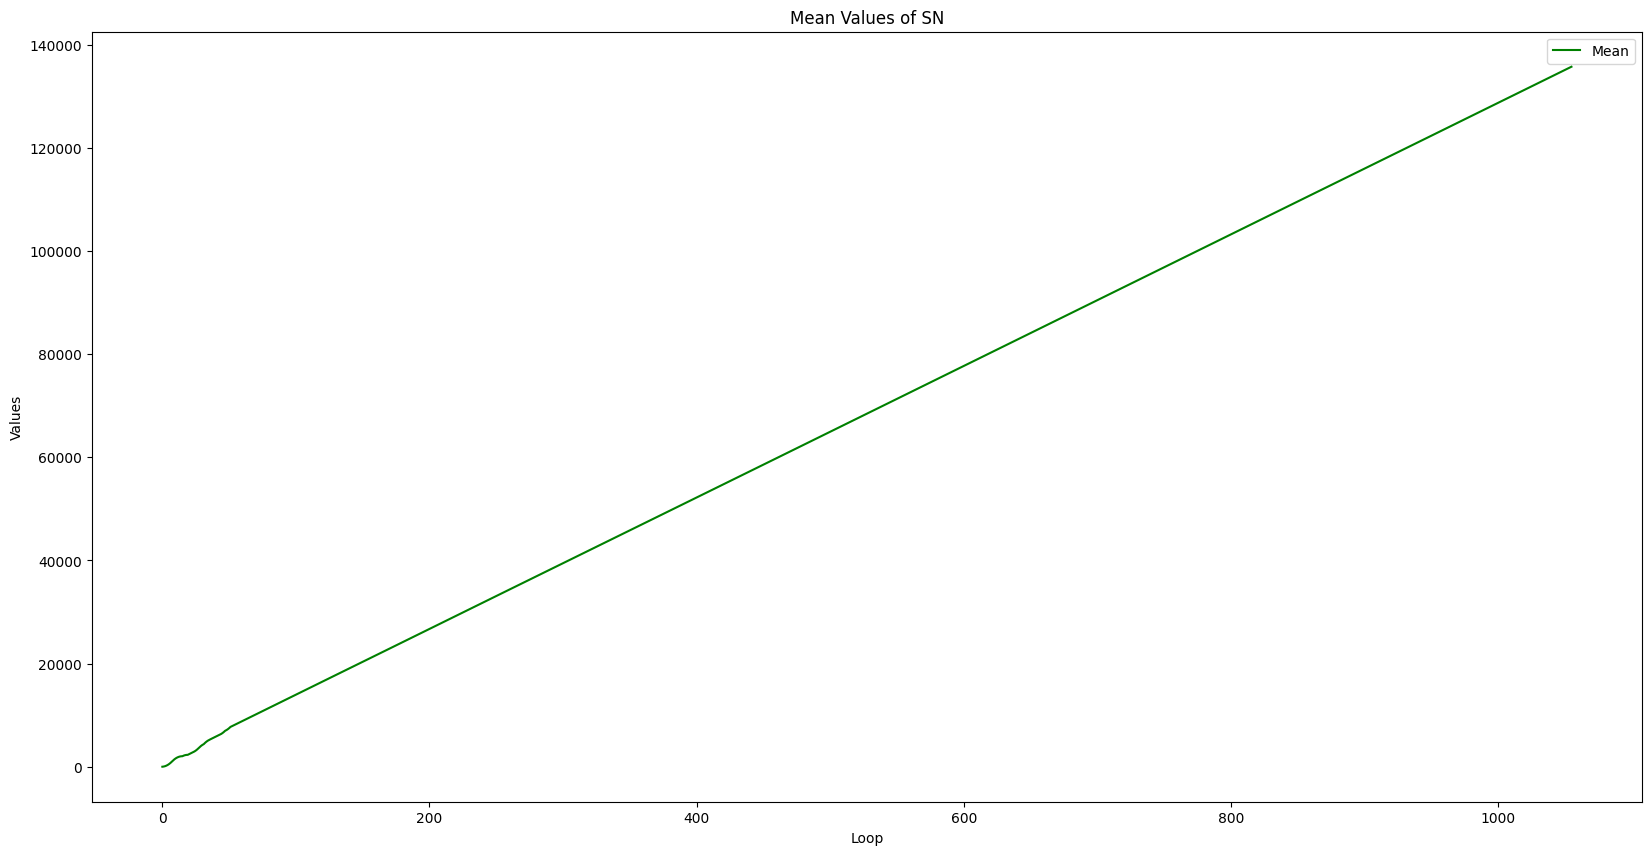

In [67]:
plt.figure(figsize=(20, 10))
plt.plot(mean, label='Mean', color='green')
plt.legend()
plt.title('Mean Values of SN')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

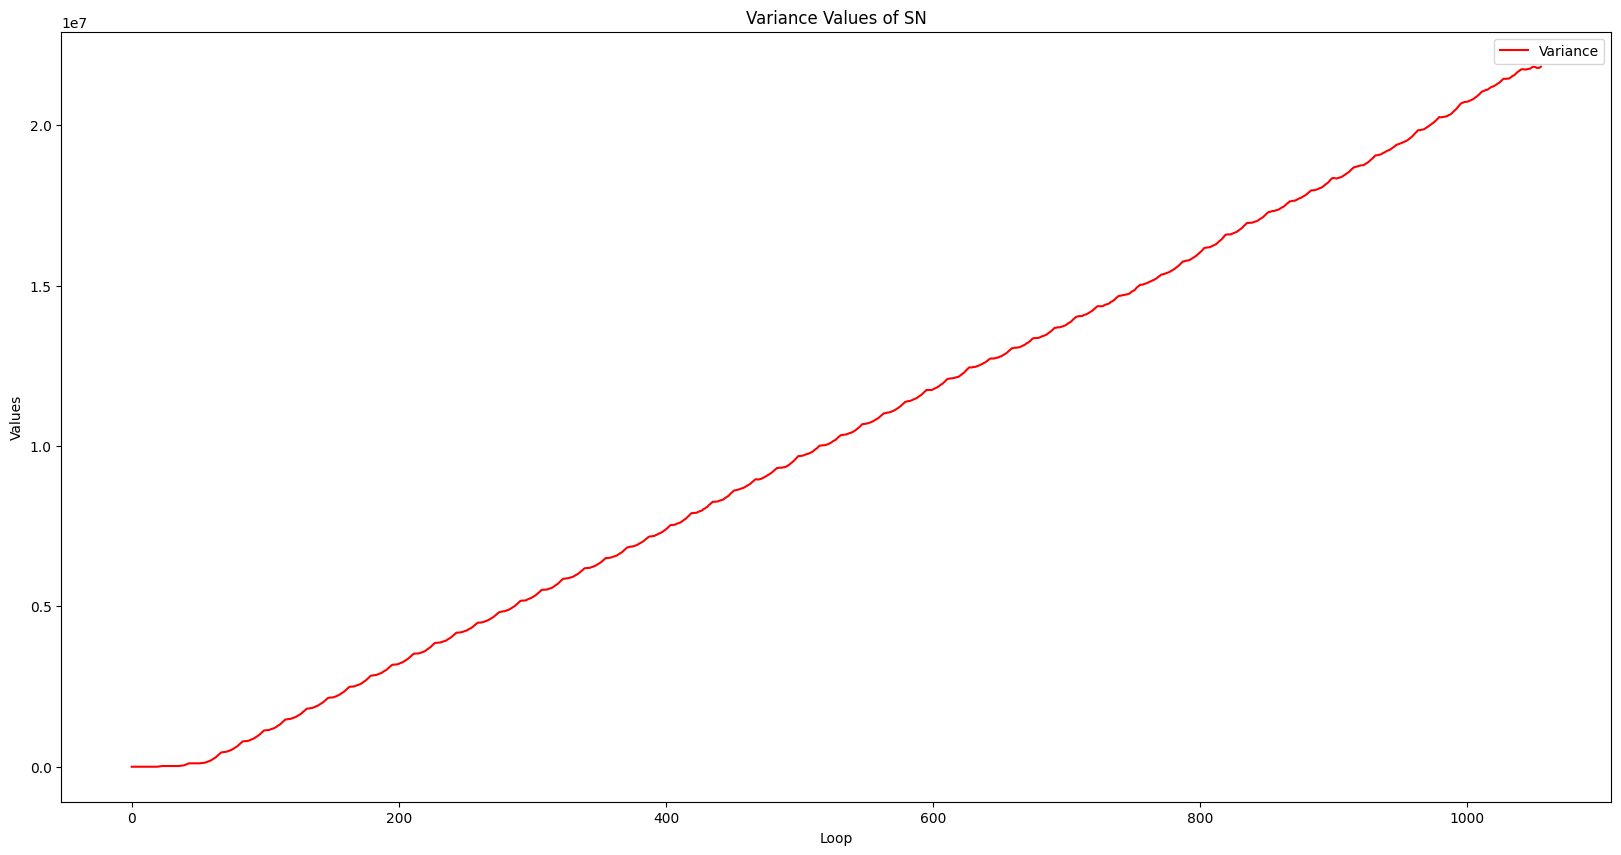

In [68]:
plt.figure(figsize=(20, 10))
plt.plot(var, label='Variance', color='red')
plt.legend()
plt.title('Variance Values of SN')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

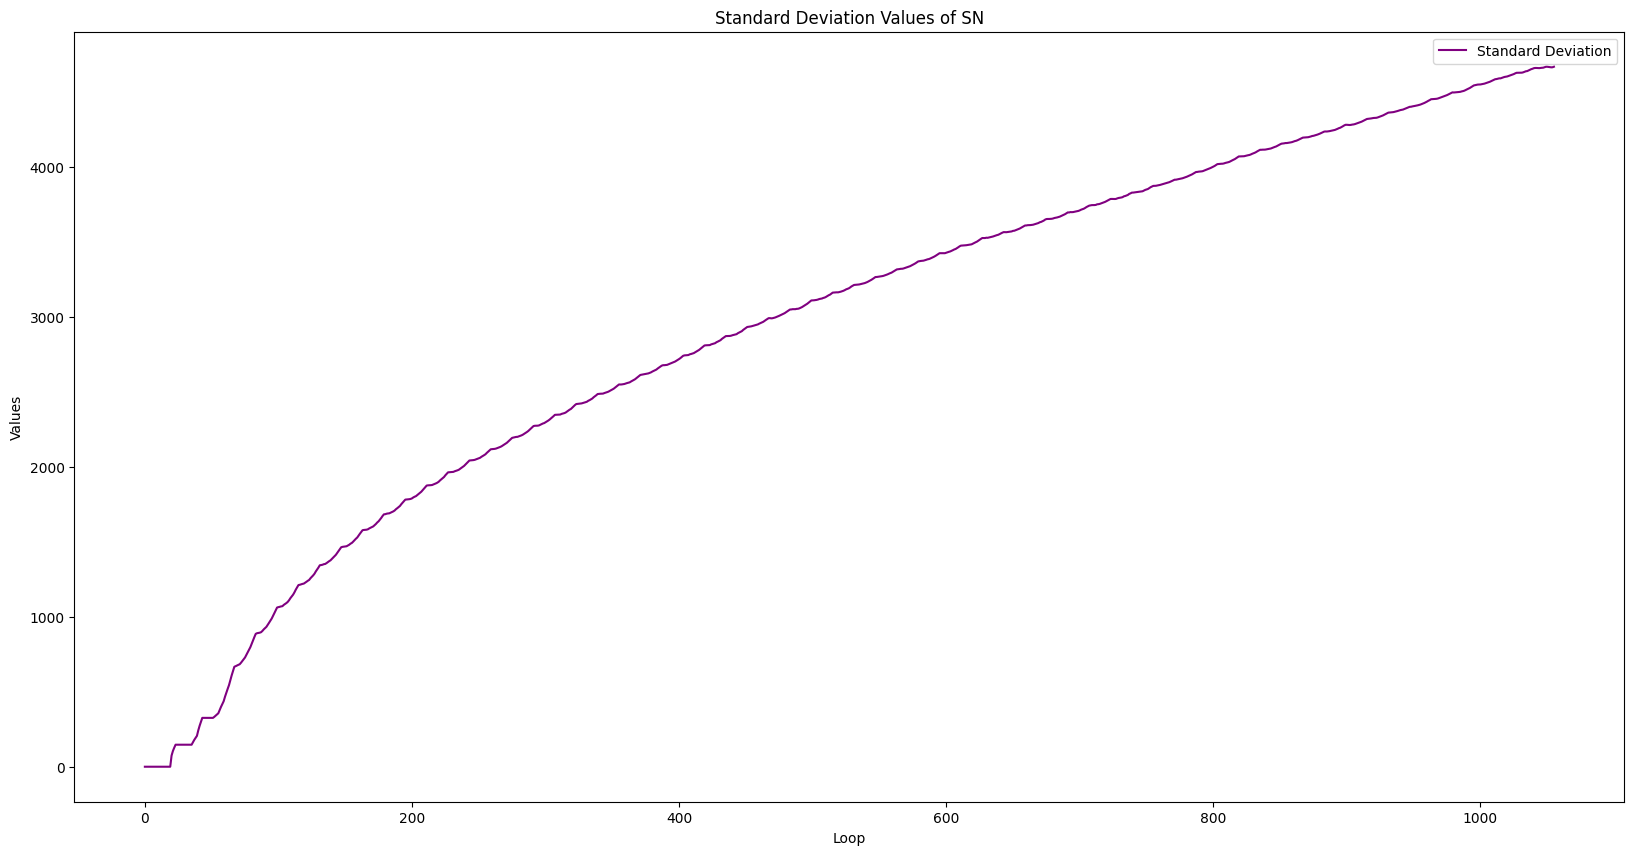

In [69]:
plt.figure(figsize=(20, 10))
plt.plot(std, label='Standard Deviation', color='purple')
plt.legend()
plt.title('Standard Deviation Values of SN')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

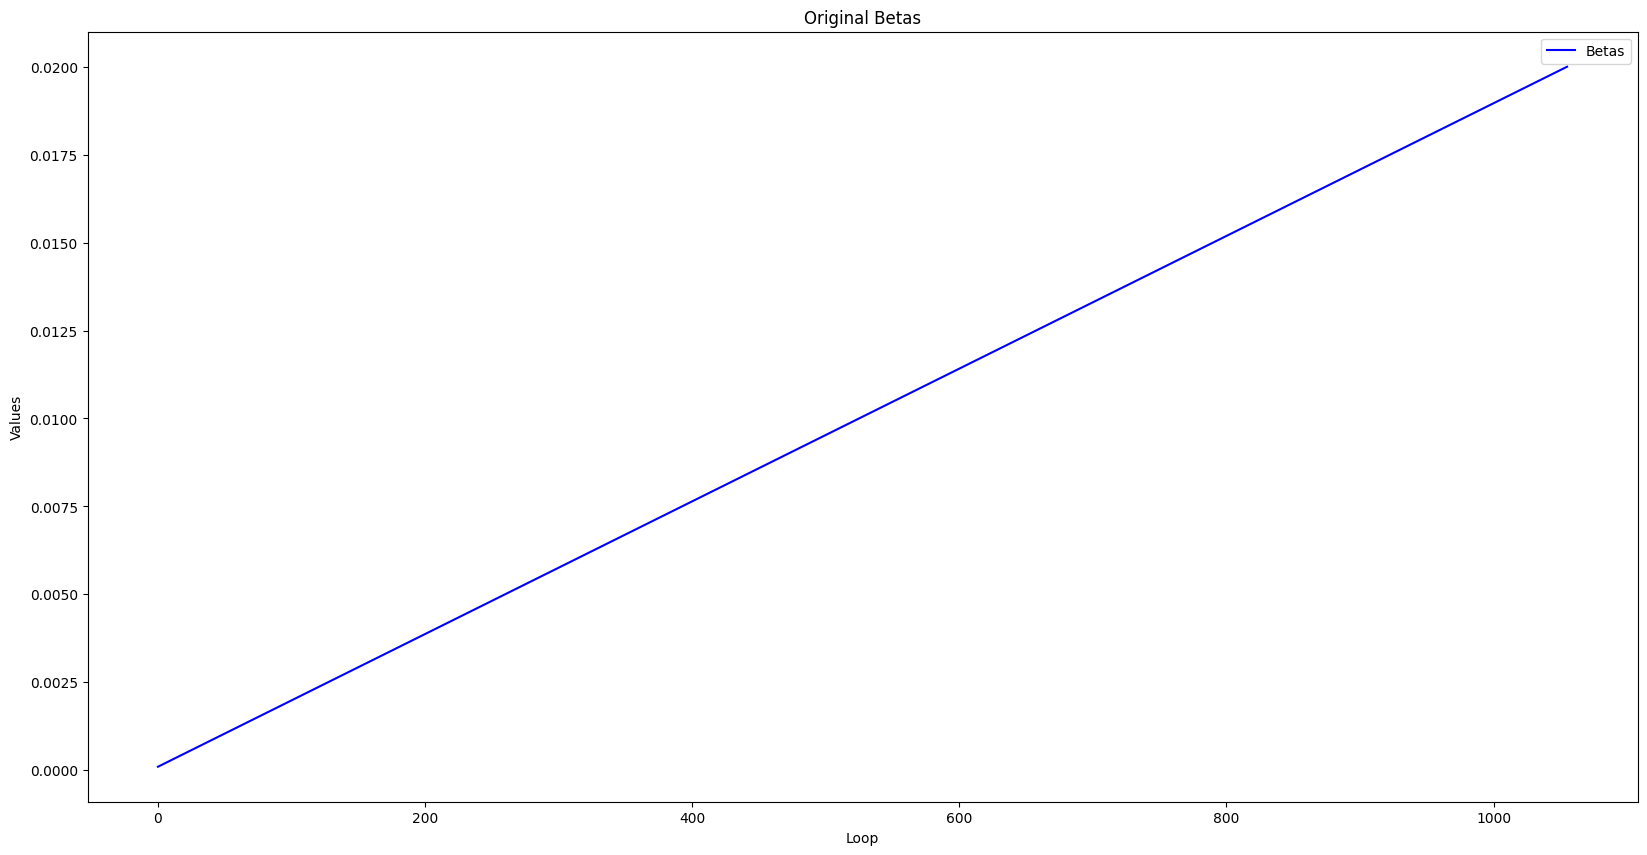

In [70]:
plt.figure(figsize=(20, 10))
plt.plot(betas, label='Betas', color='blue')
plt.legend()
plt.title('Original Betas')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

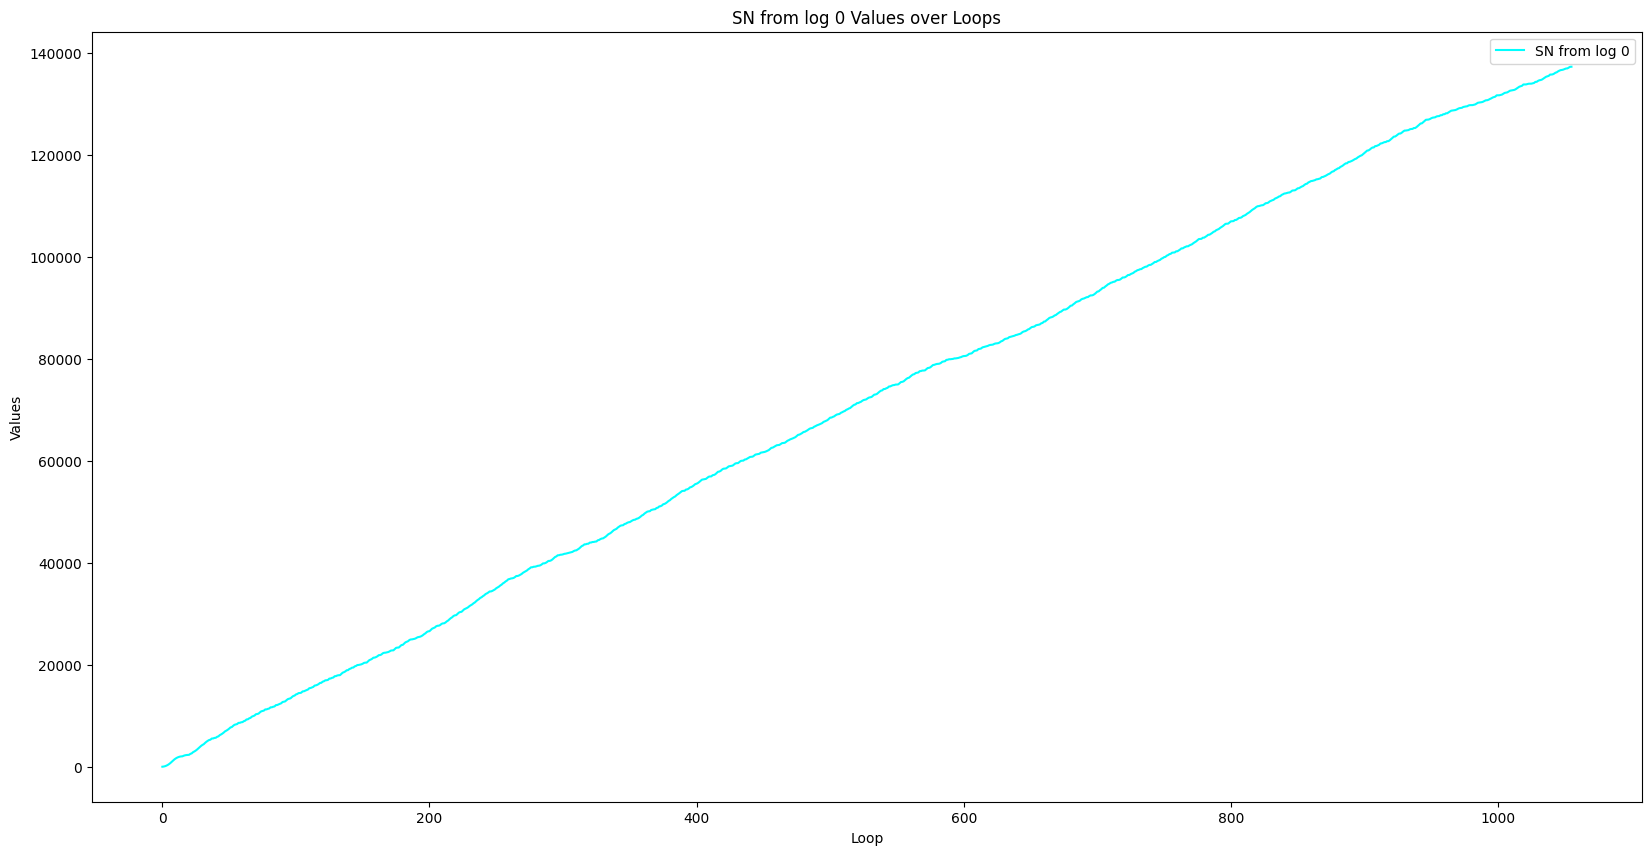

In [71]:
plt.figure(figsize=(20, 10))
plt.plot(sn_array[0], label='SN from log 0', color='cyan')
plt.legend()
plt.title('SN from log 0 Values over Loops')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

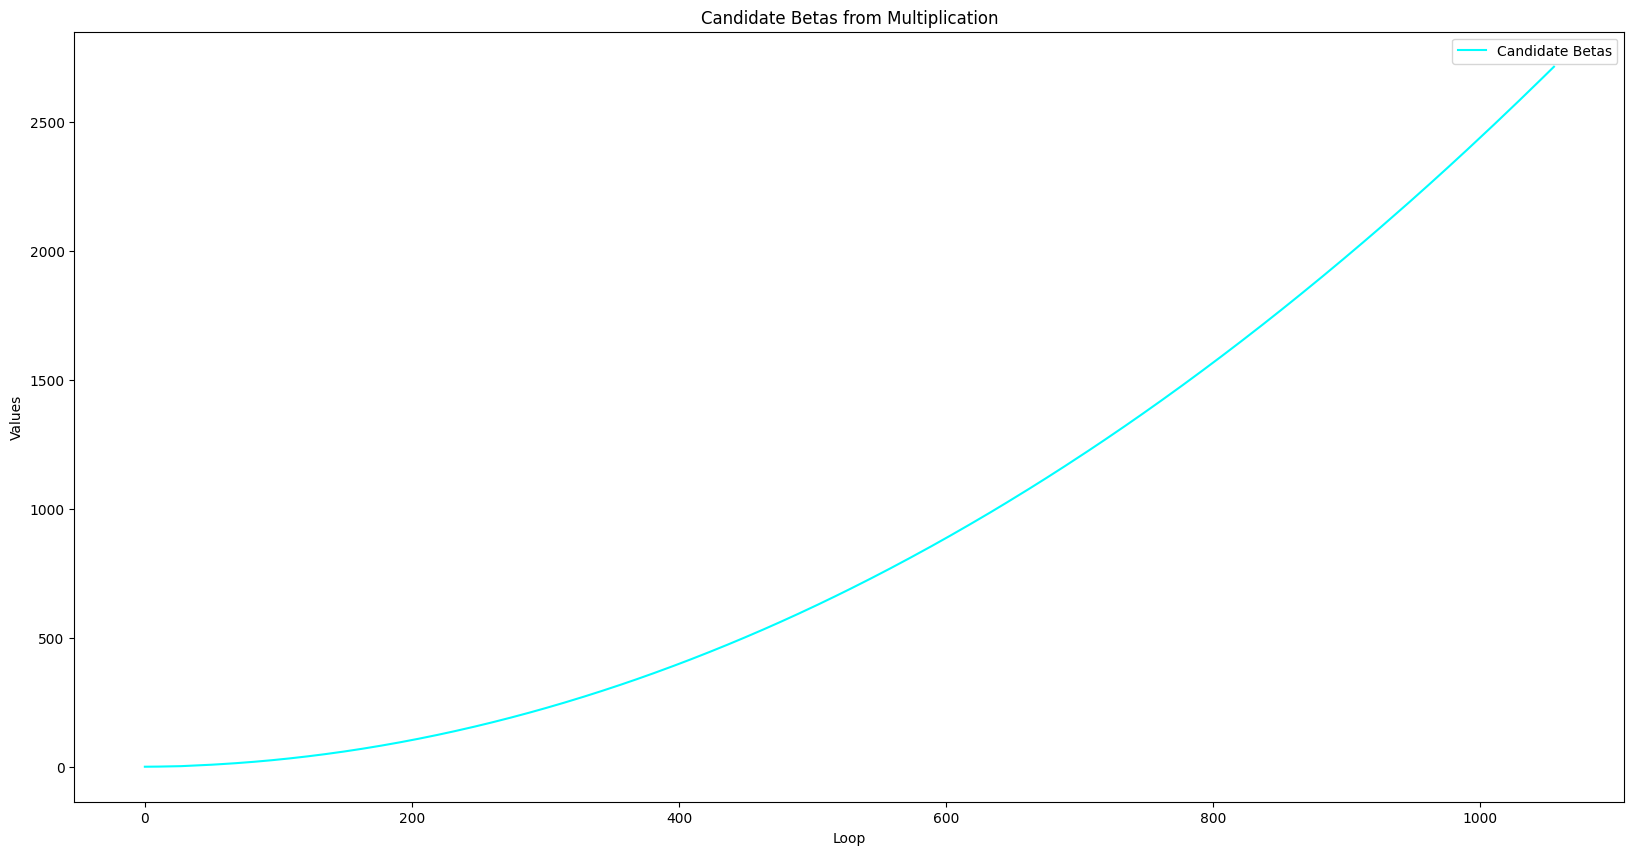

In [72]:
plt.figure(figsize=(20, 10))
plt.plot(beta_candidate_from_multiply, label='Candidate Betas', color='cyan')
plt.legend()
plt.title('Candidate Betas from Multiplication')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

In [73]:
raw_candiate_betas = np.multiply(mean, betas)
raw_min = np.min(raw_candiate_betas, axis=0)
raw_max = np.max(raw_candiate_betas, axis=0)
beta_candidate_rescaled = (raw_candiate_betas - raw_min) / (raw_max - raw_min) * (ori_beta_max - ori_beta_min) + ori_beta_min
beta_candidate_rescaled = np.clip(beta_candidate_rescaled, ori_beta_min, ori_beta_max)
beta_candidate_rescaled = np.array(beta_candidate_rescaled, dtype=np.float64)
print(beta_candidate_rescaled)

[0.0001     0.00010003 0.00010011 ... 0.01992537 0.01996264 0.02      ]


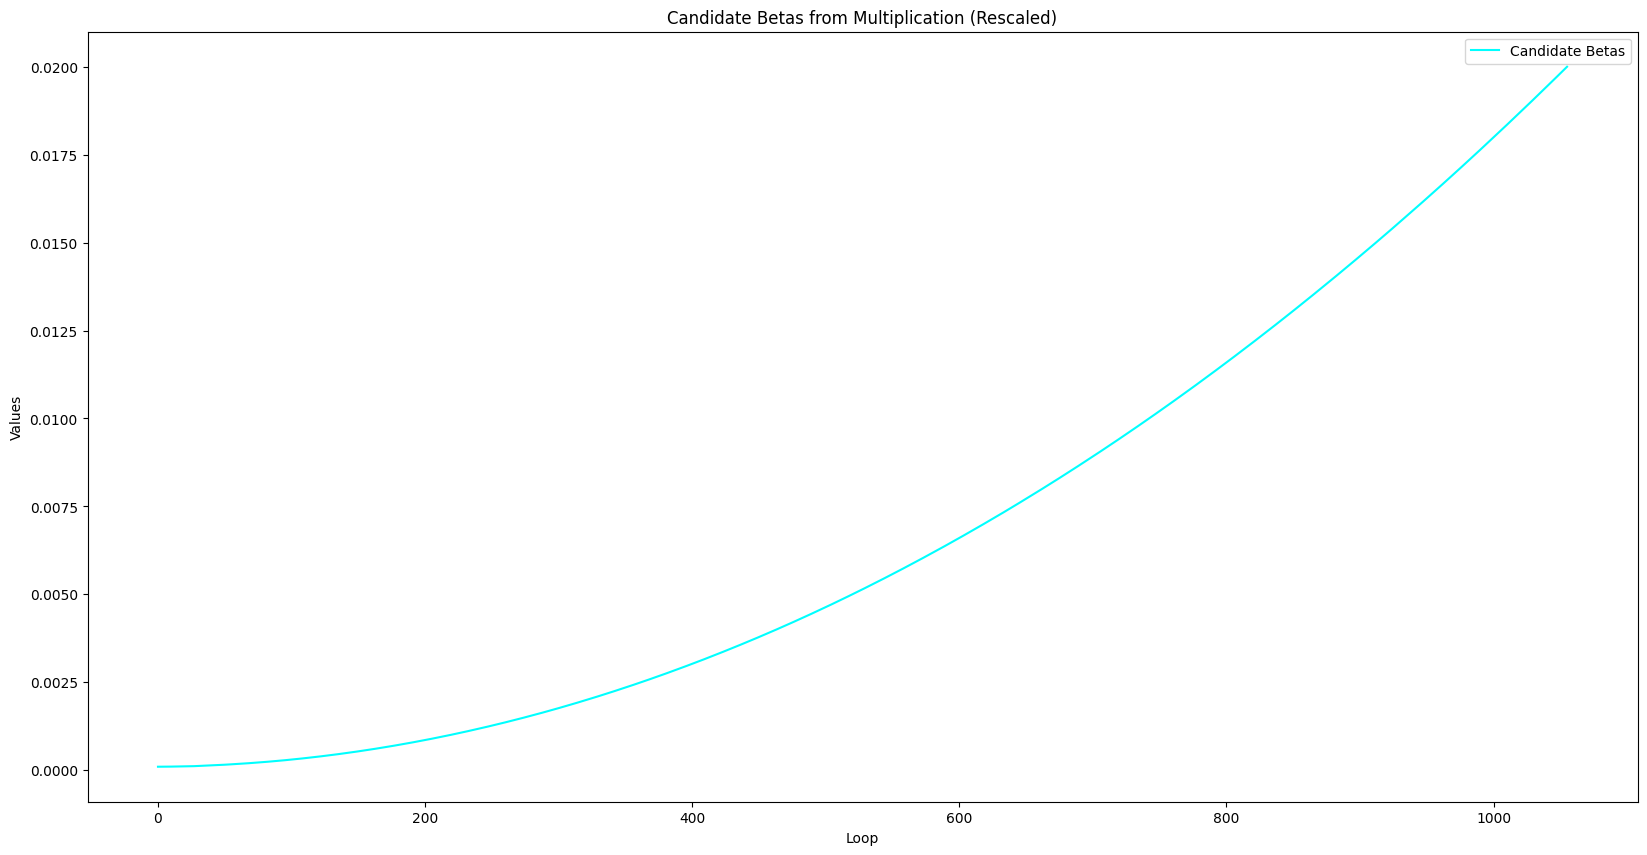

In [74]:
plt.figure(figsize=(20, 10))
plt.plot(beta_candidate_rescaled, label='Candidate Betas', color='cyan')
plt.legend()
plt.title('Candidate Betas from Multiplication (Rescaled)')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

# Beta Scheduling
## Approach 2
**method**  
1. Cumulative all bytes from Hash algorithm calculation logs  
2. Make new Beta scheduling with the cumulative sum of log bytes from intermediate computations on the x-axis  


In [75]:
print(f"Original Beta Min: {ori_beta_min}")
print(f"Original Beta Max: {ori_beta_max}")
print(f"SN Min: {sn_min}")
print(f"SN Max: {sn_max}")
linear_eq_slope = (ori_beta_max - ori_beta_min) / (sn_max - sn_min)
print(f"Linear Equation Slope: {linear_eq_slope}")

Original Beta Min: 0.0001
Original Beta Max: 0.02
SN Min: 1.0
SN Max: 135745.74839999955
Linear Equation Slope: 1.4659867313143194e-07


In [76]:
linear_equation = lambda x: linear_eq_slope * (x - sn_min) + ori_beta_min
beta_candidate_from_linear_eq = linear_equation(mean)
beta_candidate_from_linear_eq = np.array(beta_candidate_from_linear_eq, dtype=np.float64)
print(beta_candidate_from_linear_eq)

[0.0001     0.00010513 0.00011525 ... 0.01996284 0.01998139 0.02      ]


In [77]:
delta = betas - beta_candidate_from_linear_eq
print(f"Max abs delta: {np.max(np.abs(delta))}")
print(f"Delta preview: {delta[:16]}")


Max abs delta: 0.0001697070064279561
Delta preview: [ 0.00000000e+00  1.37316057e-05  2.24788565e-05  2.62417524e-05  2.50202934e-05  1.88144795e-05  7.62431080e-06 -8.55021284e-06 -2.69237166e-05
 -4.03128654e-05 -4.87176594e-05 -5.21380985e-05 -5.05741826e-05 -4.40259119e-05 -3.24932864e-05 -1.59763059e-05]


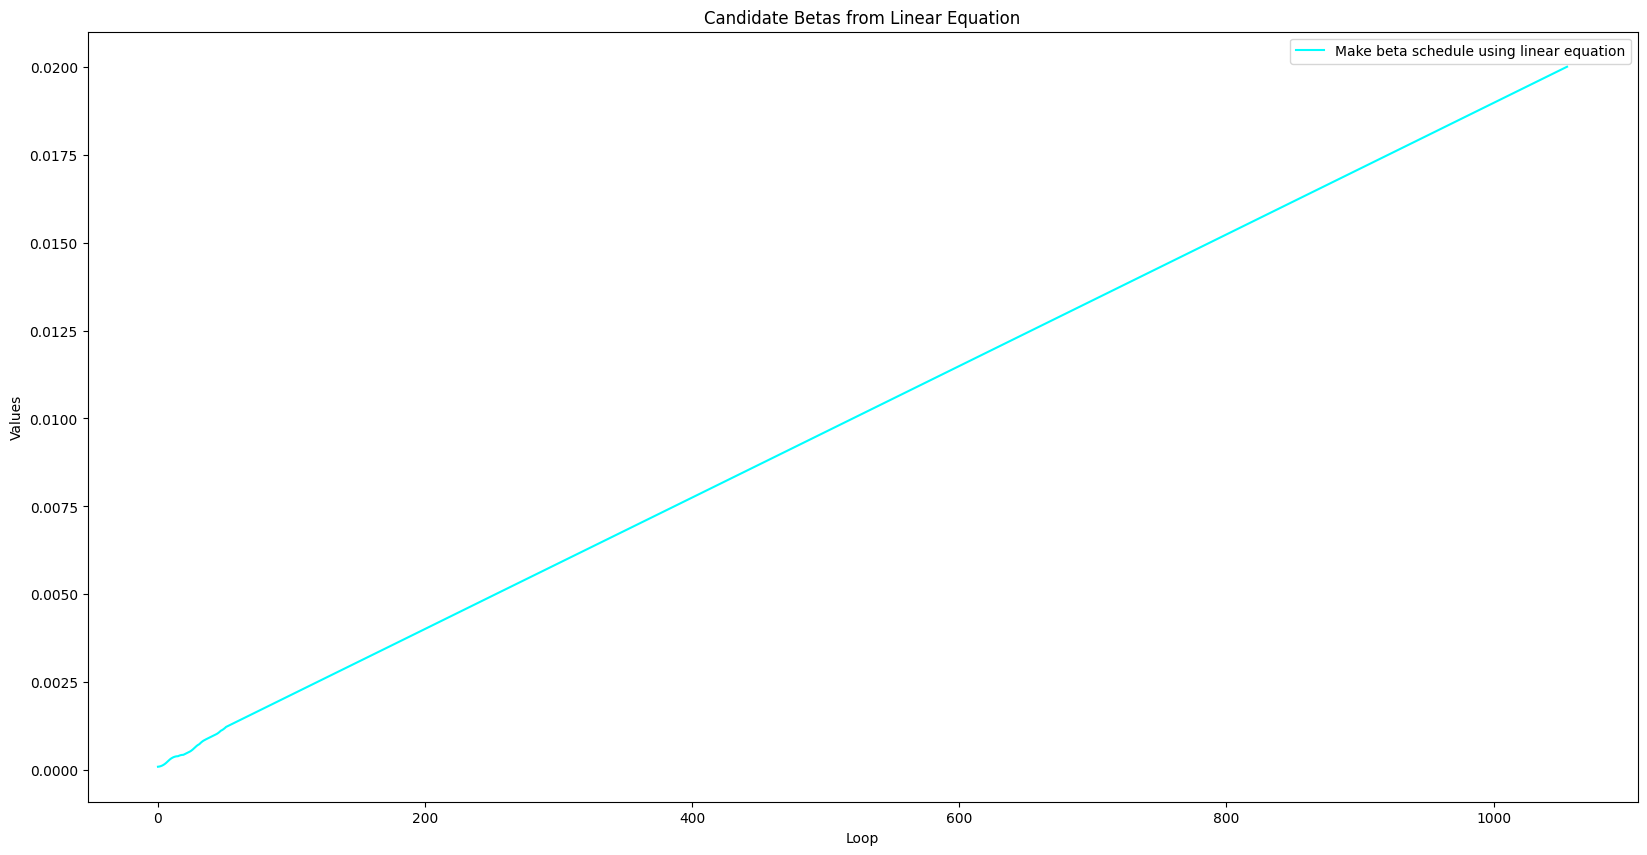

In [78]:
plt.figure(figsize=(20, 10))
plt.plot(beta_candidate_from_linear_eq, label='Make beta schedule using linear equation', color='cyan')
plt.legend()
plt.title('Candidate Betas from Linear Equation')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()